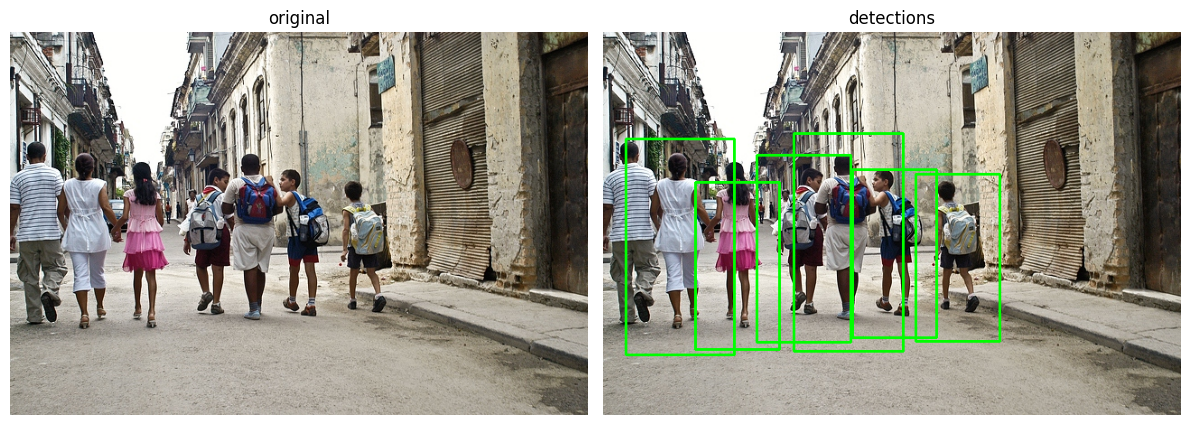

In [1]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('data/people.jpg')

hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor.getDefaultPeopleDetector())

locations, weights = hog.detectMultiScale(image)

dbg_image = image.copy()
for loc in locations:
    cv2.rectangle(dbg_image, (loc[0], loc[1]),
                         (loc[0]+loc[2], loc[1]+loc[3]), (0, 255, 0), 2)

plt.figure(figsize=(12,6))
plt.subplot(121)
plt.title('original')
plt.axis('off')
plt.imshow(image[:,:,::-1])
plt.subplot(122)
plt.title('detections')
plt.axis('off')
plt.imshow(dbg_image[:,:,::-1])
plt.tight_layout()
plt.show()

In [2]:
import cv2
import numpy as np

CELL_SIZE = 20
NCLASSES = 10
TRAIN_RATIO = 0.8

digits_img = cv2.imread('data/digits.png', 0)
digits = [np.hsplit(r, digits_img.shape[1] // CELL_SIZE)
          for r in np.vsplit(digits_img, digits_img.shape[0] // CELL_SIZE)]
digits = np.array(digits).reshape(-1, CELL_SIZE, CELL_SIZE)
nsamples = digits.shape[0]
labels = np.repeat(np.arange(NCLASSES), nsamples // NCLASSES)

for i in range(nsamples):
    m = cv2.moments(digits[i])
    if m['mu02'] > 1e-3:
        s = m['mu11'] / m['mu02']
        M = np.float32([[1, -s, 0.5*CELL_SIZE*s],
                        [0, 1, 0]])
        digits[i] = cv2.warpAffine(digits[i], M, (CELL_SIZE, CELL_SIZE))

perm = np.random.permutation(nsamples)
digits = digits[perm]
labels = labels[perm]

ntrain = int(TRAIN_RATIO * nsamples)
ntest = nsamples - ntrain

def calc_hog(digits):
    win_size = (20, 20)
    block_size = (10, 10)
    block_stride = (10, 10)
    cell_size = (10, 10)
    nbins = 9
    hog = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, nbins)
    samples = []
    for d in digits: samples.append(hog.compute(d))
    return np.array(samples, np.float32)

fea_hog_train = calc_hog(digits[:ntrain])
fea_hog_test = calc_hog(digits[ntrain:])
labels_train, labels_test = labels[:ntrain], labels[ntrain:]

K = 3
knn_model = cv2.ml.KNearest_create()
knn_model.train(fea_hog_train, cv2.ml.ROW_SAMPLE, labels_train)

svm_model = cv2.ml.SVM_create()
svm_model.setGamma(2)
svm_model.setC(1)
svm_model.setKernel(cv2.ml.SVM_RBF)
svm_model.setType(cv2.ml.SVM_C_SVC)
svm_model.train(fea_hog_train, cv2.ml.ROW_SAMPLE, labels_train)

def eval_model(fea, labels, fpred):
    pred = fpred(fea).astype(np.int32)
    acc = (pred.T == labels).mean()*100

    conf_mat = np.zeros((NCLASSES, NCLASSES), np.int32)
    for c_gt, c_pred in zip(labels, pred):
        conf_mat[c_gt, c_pred] += 1

    return acc, conf_mat

knn_acc, knn_conf_mat = eval_model(fea_hog_test, labels_test,
                                  lambda fea: knn_model.findNearest(fea, K)[1])
print('KNN accuracy (%):', knn_acc)
print('KNN confusion matrix:')
print(knn_conf_mat)

svm_acc, svm_conf_mat = eval_model(fea_hog_test, labels_test,
                                  lambda fea: svm_model.predict(fea)[1])
print('SVM accuracy (%):', svm_acc)
print('SVM confusion matrix:')
print(svm_conf_mat)

KNN accuracy (%): 91.3
KNN confusion matrix:
[[91  0  0  0  0  0  0  1  0  0]
 [ 1 98  0  0  0  0  0  2  1  0]
 [ 0  0 77  2  0  0  0  0  1  0]
 [ 1  0  2 99  0  2  0  1  6  0]
 [ 0  0  3  5 79  0  4  1  2  7]
 [ 0  0  0  2  1 87  4  0  2  1]
 [ 3  0  0  0  1  1 95  0  1  0]
 [ 0  0  3  4  1  0  0 93  2  2]
 [ 1  0  2  2  0  2  0  1 98  0]
 [ 1  0  0  2  3  0  0  2  1 96]]
SVM accuracy (%): 93.2
SVM confusion matrix:
[[ 91   0   0   0   0   0   0   1   0   0]
 [  0  97   0   0   1   0   0   3   0   1]
 [  0   0  77   0   1   0   0   1   1   0]
 [  1   0   1 100   0   4   0   3   1   1]
 [  0   0   2   1  87   0   5   2   2   2]
 [  0   0   0   0   2  88   3   2   2   0]
 [  2   0   1   0   0   1  96   0   1   0]
 [  0   0   2   2   1   0   0  99   0   1]
 [  2   0   1   2   0   1   0   0 100   0]
 [  1   0   0   1   2   1   0   2   1  97]]


In [3]:
import cv2
import numpy as np

def detect_faces(video_file, detector, win_title):
    cap = cv2.VideoCapture(video_file)

    while True:
        status_cap, frame = cap.read()
        if not status_cap:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        faces = detector.detectMultiScale(gray, 1.3, 5)

        for x, y, w, h in faces:
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 3)
            text_size, _ = cv2.getTextSize('Face', cv2.FONT_HERSHEY_SIMPLEX, 1, 2)
            cv2.rectangle(frame, (x, y - text_size[1]), (x + text_size[0], y), (255, 255, 255), cv2.FILLED)
            cv2.putText(frame, 'Face', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
        cv2.imshow(win_title, frame)

        if cv2.waitKey(1) == 27:
            break

    cap.release()
    cv2.destroyAllWindows()

haar_face_cascade = cv2.CascadeClassifier('data/haarcascade_frontalface_default.xml')
detect_faces('data/faces.mp4', haar_face_cascade, 'Haar cascade face detector')

lbp_face_cascade = cv2.CascadeClassifier()
lbp_face_cascade.load('data/lbpcascade_frontalface.xml')

detect_faces(0, lbp_face_cascade, 'LBP cascade face detector')

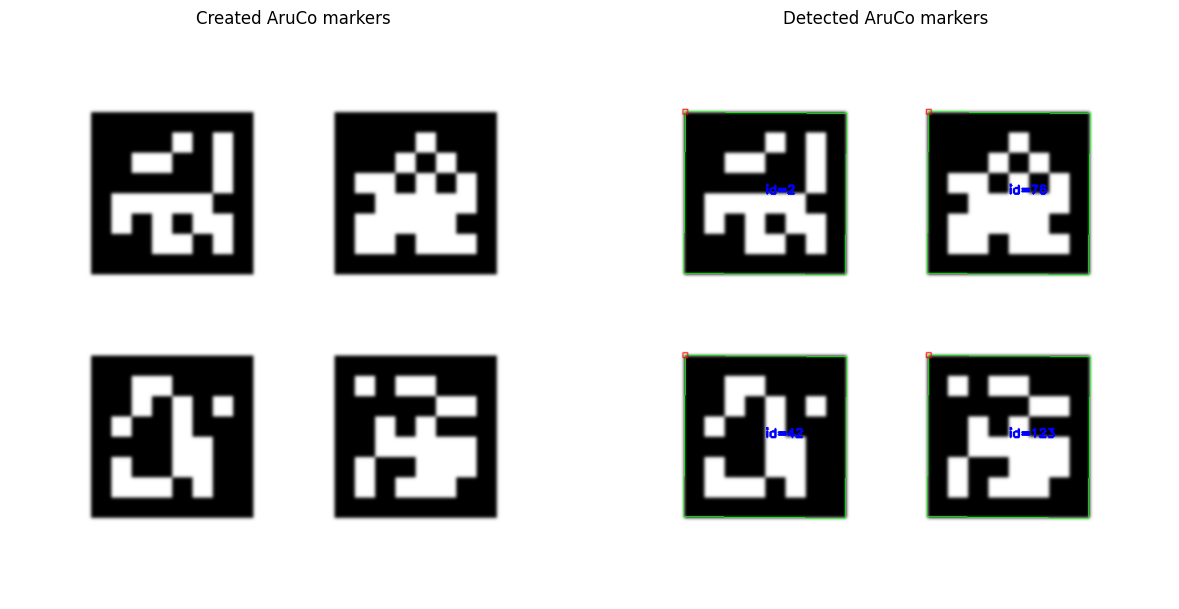

In [7]:
import cv2
import cv2.aruco as aruco
import matplotlib.pyplot as plt
import numpy as np

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_6X6_250)

img = np.full((700, 700), 255, np.uint8)

def make_marker(dictionary, marker_id, side_pixels):
    if hasattr(aruco, 'drawMarker'):
        return aruco.drawMarker(dictionary, marker_id, side_pixels)
    return aruco.generateImageMarker(dictionary, marker_id, side_pixels)

img[100:300, 100:300] = make_marker(aruco_dict, 2, 200)
img[100:300, 400:600] = make_marker(aruco_dict, 76, 200)
img[400:600, 100:300] = make_marker(aruco_dict, 42, 200)
img[400:600, 400:600] = make_marker(aruco_dict, 123, 200)

img = cv2.GaussianBlur(img, (11, 11), 0)

if hasattr(aruco, 'ArucoDetector'):
    detector = aruco.ArucoDetector(aruco_dict)
    corners, ids, _ = detector.detectMarkers(img)
else:
    corners, ids, _ = aruco.detectMarkers(img, aruco_dict)

img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
aruco.drawDetectedMarkers(img_color, corners, ids)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Created AruCo markers')
plt.axis('off')
plt.imshow(img, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Detected AruCo markers')
plt.axis('off')
plt.imshow(img_color[:, :, ::-1])

plt.tight_layout()
plt.show()